In [1]:
import pandas as pd
import matplotlib.pyplot as plt

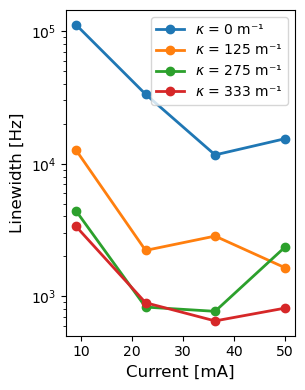

In [7]:
# Load the dataset
df2 = pd.read_csv("summary_linewidth_vs_coupling.csv")

plt.figure(figsize=(6.3/2, 4))

# Group by coupling (kappa) and plot each line
for coupling_value, group in df2.groupby("coupling"):
    plt.plot(
        group["current_mA"],
        group["linewidth_MHz"]*1E6,
        marker="o",
        linewidth=2,
        label=f"$\kappa$ = {coupling_value*1E6:g} m⁻¹",
    )

# Use a logarithmic scale for the y-axis due to wide range of values
plt.yscale("log")

# Labeling and formatting
plt.xlabel("Current [mA]", fontsize=12)
plt.ylabel("Linewidth [Hz]", fontsize=12)
#plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=10)

plt.tight_layout()
#plt.savefig(r"C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\Methods & Results\linewidth_current.png",dpi=300)
plt.show()

Loading summary from: C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official\summary_linewidth_vs_coupling.csv
Plot saved successfully to:
C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official\linewidth_vs_feedback_Hz.png


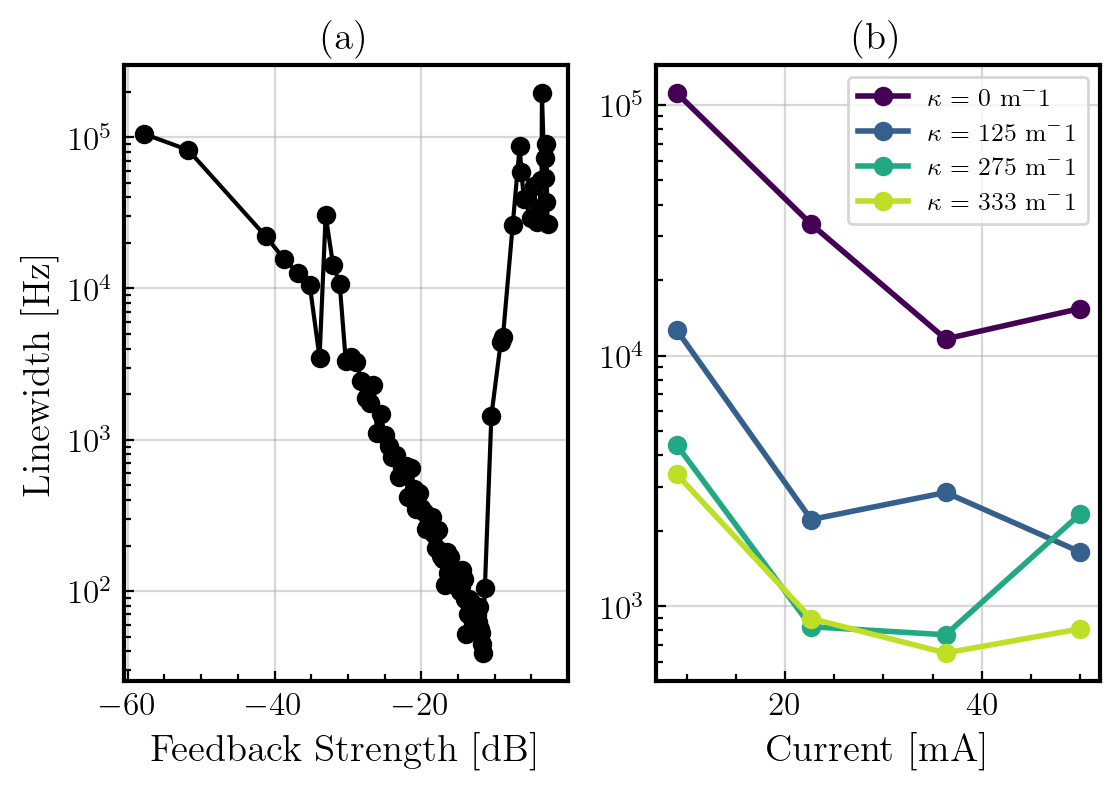

<Figure size 630x800 with 0 Axes>

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

maj_tick_width = 0.8
min_tick_width = 0.8

plot_params = {
    "figure.dpi": 200,
    "axes.labelsize": 14,
    "axes.linewidth": 1.5,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.title_fontsize": 11,
    "legend.fontsize": 11,
    "xtick.major.size": 3.5,
    "xtick.major.width": maj_tick_width,
    "xtick.minor.size": 2.5,
    "xtick.minor.width": min_tick_width,
    "ytick.major.size": 3.5,
    "ytick.major.width": maj_tick_width,
    "ytick.minor.size": 2.5,
    "ytick.minor.width": min_tick_width,
    "font.family": "serif",
    "text.usetex": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pgf.texsystem": "pdflatex",
    "pgf.rcfonts": False,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
}

plt.rcParams.update(plot_params)
# -----------------------------------------------------------------------------
# 1. User Settings & File Paths
# -----------------------------------------------------------------------------
folder_path = r"C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official"
summary_path = os.path.join(folder_path, "summary_linewidth_vs_coupling.csv")
npz_path = os.path.join(folder_path, "linewidth_and_psd_coarse.npz")
# -----------------------------------------------------------------------------
# 2. Data Loading (Tries summary CSV first, falls back to .npz)
# -----------------------------------------------------------------------------
if os.path.isfile(summary_path):
    print(f"Loading summary from: {summary_path}")
    df = pd.read_csv(summary_path)
    
    # Filter valid non-NaN rows
    valid_mask = np.isfinite(df["feedback_strength_dB"]) & np.isfinite(df["linewidth_MHz"])
    df_valid = df[valid_mask].copy()
    
    # Sort by feedback strength for a clean continuous line
    df_valid = df_valid.sort_values(by="feedback_strength_dB")
    
    feedback_dB = df_valid["feedback_strength_dB"].values
    linewidth_Hz = df_valid["linewidth_MHz"].values * 1e6  # Convert MHz to Hz
elif os.path.isfile(npz_path):
    print(f"Loading from NPZ cache: {npz_path}")
    data = np.load(npz_path)
    
    sort_idx = np.argsort(data["feedback_sorted"])
    feedback_dB = data["feedback_sorted"][sort_idx]
    linewidth_Hz = data["linewidth_sorted"][sort_idx] * 1e6  # Convert MHz to Hz
else:
    raise FileNotFoundError(f"Could not find summary CSV or NPZ file in: {folder_path}")
# -----------------------------------------------------------------------------
# 3. Plotting Linewidth (Hz) vs Feedback Strength (dB)
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(1,2,figsize=(6.3, 4))
# Main curve plot
ax[0].plot(feedback_dB, linewidth_Hz, "o-", label="This work",color='black')
# Formatting Axes
ax[0].set_yscale("log")
ax[0].set_xlabel("Feedback Strength [dB]")
ax[0].set_ylabel("Linewidth [Hz]")
# Optional styling matching typical paper layouts
ax[0].grid(True,alpha=0.5)
# Add a light indicator line for 1 Hz if your linewidth drops into sub-Hz
#if np.min(linewidth_Hz) < 100:
    #ax[0].axhline(1.0, color="yellow", linestyle=":", alpha=0.7, label="1 Hz benchmark")
#ax[0].axvline(x=feedback_dB[np.argmin(linewidth_Hz)],color='red')
plt.figure(figsize=(6.3/2, 4))
# Group by coupling (kappa) and plot each line, colored with viridis
# (4 distinct coupling strengths -> 4 evenly spaced viridis shades)
n_couplings = df2["coupling"].nunique()
coupling_colors = plt.cm.viridis(np.linspace(0, 0.9, n_couplings))
for color_idx, (coupling_value, group) in enumerate(df2.groupby("coupling")):
    ax[1].plot(
        group["current_mA"],
        group["linewidth_MHz"]*1E6,
        marker="o",
        linewidth=2,
        color=coupling_colors[color_idx],
        label=f"$\kappa$ = {coupling_value*1E6:g} m$^{-1}$",
    )
# Use a logarithmic scale for the y-axis due to wide range of values
ax[1].set_yscale("log")
df3 = pd.read_csv(r'C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Bowers_1kL.csv',names=['x','y'])
#ax[0].plot(df3['x'],df3['y'],label='Dong et al. (2025)')
#ax[0].set_xlim(-58,-2)
#ax[0].legend()
# Labeling and formatting
ax[1].set_xlabel("Current [mA]")
#ax[1].set_ylabel("Linewidth [Hz]", fontsize=12)
#plt.grid(True, which="both", linestyle="--", alpha=0.5)
ax[1].legend(fontsize=9)
ax[0].set_title('(a)')

ax[1].set_title('(b)')
ax[1].grid(True,alpha=0.5)
plt.tight_layout()
# Save output figure
output_image = os.path.join(folder_path, "linewidth_vs_feedback_Hz.png")
#plt.savefig(output_image, dpi=300, bbox_inches="tight")
fig.savefig(r"C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\pgf_figures\linewidth_current.pgf",dpi=300)
print(f"Plot saved successfully to:\n{output_image}")
plt.show()